<img src="https://embit.ru/wp-content/uploads/2023/02/935181-564x150.png" width="800" align="center">

<hr>

# 📚 Содержание

0. Импорты и загрузка данных  
1. Информация по датасету
2. μ(x) Модель матожидания 
3. σ²(x) Модель дисперсии
4. Outcome модель
5. Dose-response кривая 
6. Bootstrap 
7. График влияния Treatment на RR4W
8. Проверка баланса после GPS
9. Оценка эффекта   


<hr>

## 💿 Импорты и загрузка данных

In [120]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")
np.random.seed(2025)

# ---------------- 0) Загрузка ----------------
DATA_PATH = "GPS.csv"
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, sep=';')
    print(f"Loaded {DATA_PATH} with shape {df.shape}")
else:
    raise FileNotFoundError(f"Error: no such file {DATA_PATH}")

covariate_cols = ['sum_time_info_sec_prev', 'sum_time_sec_prev', 'sum_time_main_sec_prev',
                 'sessions_cnt_day_prev', 'age_years', 'delta_days']

df = df.dropna()

df['T_raw'] = df['T']
df['Y_raw'] = df['Y']

df['T'] = np.log1p(df['T_raw'])
df['Y'] = np.log1p(df['Y_raw'])

Loaded GPS.csv with shape (524367, 9)


In [121]:
df.head()

,user_id,sum_time_info_sec_prev,sum_time_sec_prev,T,sum_time_main_sec_prev,sessions_cnt_day_prev,age_years,delta_days,Y,T_raw,Y_raw
0,44224093,68.0,20900.0,0.000000,6571.0,9.0,43,76,0.0,0.0,0
1,44224141,11.0,6623.0,3.401197,1248.0,12.0,42,1,0.0,29.0,0
2,44224141,18.0,23633.0,5.429346,4476.0,23.0,42,1,0.0,227.0,0
3,44224141,19.0,34858.0,6.086775,7011.0,20.0,42,1,0.0,439.0,0
4,44224141,36.0,45125.0,6.113682,9569.0,11.0,42,1,0.0,451.0,0


<hr>

<h2>📋 Информация по датасету:</h2>
<p>
    <ul>
        <li>sum_time_info_sec_prev - кумулятивная сумма по информационному разделу за прошлую дату, ссылки из которого ведут в наш раздел</li>
        <li>sum_time_sec_prev - кумулятивная сумма по всему сайту за прошлую дату</li>
        <li>sum_time_main_sec_prev - кумулятивная сумма по главному разделу за прошлую дату, откуда можно попасть в наш раздел</li>
        <li>sessions_cnt_day_prev - количество сессий в нашем разделе за прошлую дату</li>
        <li>age_years - возраст</li>
        <li>delta_days - количество дней без захода в наш раздел</li>
        <li>T-Treatment - время проведенное в нашем разделе</li>
        <li>Y-target - Retention Rate 4 Week (первая неделя нулевая, поэтому считается посещение раздела на 5 неделе)</li>
</p>

In [122]:
df.head()

,user_id,sum_time_info_sec_prev,sum_time_sec_prev,T,sum_time_main_sec_prev,sessions_cnt_day_prev,age_years,delta_days,Y,T_raw,Y_raw
0,44224093,68.0,20900.0,0.000000,6571.0,9.0,43,76,0.0,0.0,0
1,44224141,11.0,6623.0,3.401197,1248.0,12.0,42,1,0.0,29.0,0
2,44224141,18.0,23633.0,5.429346,4476.0,23.0,42,1,0.0,227.0,0
3,44224141,19.0,34858.0,6.086775,7011.0,20.0,42,1,0.0,439.0,0
4,44224141,36.0,45125.0,6.113682,9569.0,11.0,42,1,0.0,451.0,0


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524367 entries, 0 to 524366
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   user_id                 524367 non-null  int64  
 1   sum_time_info_sec_prev  524367 non-null  float64
 2   sum_time_sec_prev       524367 non-null  float64
 3   T                       524367 non-null  float64
 4   sum_time_main_sec_prev  524367 non-null  float64
 5   sessions_cnt_day_prev   524367 non-null  float64
 6   age_years               524367 non-null  int64  
 7   delta_days              524367 non-null  int64  
 8   Y                       524367 non-null  float64
 9   T_raw                   524367 non-null  float64
 10  Y_raw                   524367 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 44.0 MB


In [124]:
df.describe()

,user_id,sum_time_info_sec_prev,sum_time_sec_prev,T,sum_time_main_sec_prev,sessions_cnt_day_prev,age_years,delta_days,Y,T_raw,Y_raw
count,5.243670e+05,524367.000000,5.243670e+05,524367.000000,5.243670e+05,524367.000000,524367.000000,524367.000000,524367.000000,524367.000000,524367.000000
mean,4.538325e+07,1813.866353,1.324110e+05,3.302301,7.311933e+04,8.830695,32.410939,10.015258,0.312046,513.104886,0.450187
std,6.238863e+05,3963.168788,1.721027e+05,2.816743,1.084860e+05,8.535713,10.759809,21.140484,0.344850,2418.635501,0.497513
min,4.422409e+07,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,4.485696e+07,167.000000,2.368200e+04,0.000000,9.966000e+03,2.000000,24.000000,0.000000,0.000000,0.000000,0.000000
50%,4.543456e+07,647.000000,6.944000e+04,3.526361,3.301000e+04,6.000000,30.000000,1.000000,0.000000,33.000000,0.000000
75%,4.589613e+07,1848.000000,1.704745e+05,5.666427,8.937700e+04,14.000000,39.000000,9.000000,0.693147,288.000000,1.000000
max,4.648239e+07,179459.000000,1.981214e+06,12.639931,1.501416e+06,65.000000,948.000000,203.000000,0.693147,308639.000000,1.000000


<hr>

<h2>μ(x) Модель матожидания</h2>

In [125]:
model_t = RandomForestRegressor(n_estimators=500, min_samples_leaf=10, random_state=42)
model_t.fit(df[covariate_cols], df['T'])
mu_hat = model_t.predict(df[covariate_cols])

### Оценка качества модели
<p>Поскольку данная модель не является предсказательной, лучшей метрикой будет r2 - насколько хорошо модель описывает дисперсию случайной величины (таргета)</p>

In [126]:
print(r2_score(mu_hat, df['T']))

0.40278237247487547


<p>Для предсказательной модели такой показатель был бы недостаточным, но в данной задаче нас устроит любое значение выше 0.1</p>

<hr>

## σ²(x) Модель дисперсии

In [127]:
resid = df['T'] - mu_hat
var_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=2)
var_model.fit(df[covariate_cols], resid**2)
sigma2_hat = var_model.predict(df[covariate_cols])
sigma2_hat = np.maximum(sigma2_hat, 1e-6)
sigma_hat = np.sqrt(sigma2_hat)

df['mu_hat'] = mu_hat     
df['sigma_hat'] = sigma_hat

T = df['T']

<hr>

## ⚖️ GPS
<p>Поскольку мы обучаем модель на логарифмированном таргете, при подсчете GPS мы используем norm.logpdf из scipy.scats <br>
logpdf вычисляет логарифм плотности вероятности (log-pdf) нормального распределения в точках T при параметрах loc=mu_hat (мат. ожидание) и scale=sigma_hat (стандартное отклонение). <br>
Потом восстанавливаем через экспоненту, чтобы получить истинное значение плотности вероятности.</p>

In [128]:
log_gps_obs = norm.logpdf(T, loc=mu_hat, scale=sigma_hat)
gps_obs = np.exp(log_gps_obs)
df['gps'] = gps_obs
df['log_gps'] = log_gps_obs

print("GPS summary:")
print(df[['T','mu_hat','sigma_hat','gps']].describe())

GPS summary:
                   T         mu_hat      sigma_hat            gps
count  524367.000000  524367.000000  524367.000000  524367.000000
mean        3.302301       3.301453       1.431341       3.673948
std         2.816743       1.949154       0.471552      36.025179
min         0.000000       0.000000       0.001000       0.000000
25%         0.000000       1.770350       1.214114       0.131603
50%         3.526361       3.299659       1.517695       0.201613
75%         5.666427       4.749159       1.790777       0.274064
max        12.639931      10.160525       4.788543     398.942280


<hr>

## 🏁 Outcome модель
<p>Теперь мы можем обучить полиномиальную логистическую регрессию с 2 фичами Treatment и GPS. <br>
Так как GPS "вобрал" в себя все остальные фичи, он будет балансировать Treatment.</p>

In [129]:
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
TP = poly.fit_transform(df[['T','gps']])
X_out = sm.add_constant(TP, has_constant='add')
out_model = sm.OLS(df['Y'].values, X_out).fit(cov_type='HC3')
params = np.asarray(out_model.params)

print("\nOutcome model coefficients (polynomial basis):")
feature_names = ['const'] + poly.get_feature_names_out(['T','gps']).tolist()
for name, val in zip(feature_names, params):
    print(f"{name:12s} {val:.6f}")


Outcome model coefficients (polynomial basis):
const        0.309007
T            -0.014469
gps          0.000744
T^2          0.002572
T gps        0.001902
gps^2        -0.000001


<hr>

## 📈 Dose-response кривая
<p>Следующим шагом мы хотим посчитать, как изменяется наш Y, в зависимости от разного уровня воздействия Treatment. <br>
Другими словами, давайте представим себе, что мы можем назначить пользователю любое время посещения и посмотреть<br>
какая реакция произойдет</p>

In [130]:
t_grid = np.linspace(df['T'].min(), df['T'].max(), 60)
mu_hat_t = []
n = df.shape[0]
for t_star in t_grid:
    log_gps_tstar = norm.logpdf(np.repeat(t_star, n), loc=mu_hat, scale=sigma_hat)
    gps_tstar = np.exp(log_gps_tstar)
    TP_star = poly.transform(np.column_stack([np.repeat(t_star, n), gps_tstar]))
    X_star = sm.add_constant(TP_star, has_constant='add')
    y_pred_i = X_star.dot(params)
    mu_hat_t.append(np.mean(y_pred_i))
mu_hat_t = np.array(mu_hat_t)

# возвращаем в исходную шкалу Y и T
t_grid_raw = np.expm1(t_grid)
mu_hat_t_raw = np.expm1(mu_hat_t)

<hr>

## 🅱️ Bootstrap
<p>Чтобы понимать, что наша оценка не является случайностью, построим доверительные интервалы с помощью бутстрапа.</p>

In [131]:
def bootstrap_dose_response(df, X_out, poly, mu_hat, sigma_hat, t_grid, B=500, seed=123):
    n = len(df)
    boot_mu = np.zeros((B, len(t_grid)))
    rng = np.random.RandomState(seed)
    

    for b in tqdm(range(B), desc="Bootstrapping", unit="iter"):
        idx = rng.randint(0, n, size=n)
        Xb = X_out[idx, :]
        Yb = df['Y'].values[idx]
        try:
            beta, *_ = np.linalg.lstsq(Xb, Yb, rcond=None)
            for j, t_star in enumerate(t_grid):
                log_gps_tstar = norm.logpdf(np.repeat(t_star, n), loc=mu_hat, scale=sigma_hat)
                gps_tstar = np.exp(log_gps_tstar)
                TP_star = poly.transform(np.column_stack([np.repeat(t_star, n), gps_tstar]))
                Xs = sm.add_constant(TP_star, has_constant='add')
                y_pred = Xs.dot(beta)
                boot_mu[b, j] = np.mean(y_pred)
        except Exception:
            boot_mu[b, :] = np.nan
    
    return boot_mu


B = 500
print(f"\nBootstrap")
boot_mu = bootstrap_dose_response(df, X_out, poly, mu_hat, sigma_hat, t_grid, B=B, seed=123)
ci_lower = np.expm1(np.nanpercentile(boot_mu, 2.5, axis=0))
ci_upper = np.expm1(np.nanpercentile(boot_mu, 97.5, axis=0))


Bootstrap


Bootstrapping: 100%|██████████| 500/500 [46:21<00:00,  5.56s/iter]


<hr>

## 📈 График влияния Treatment на RR4W

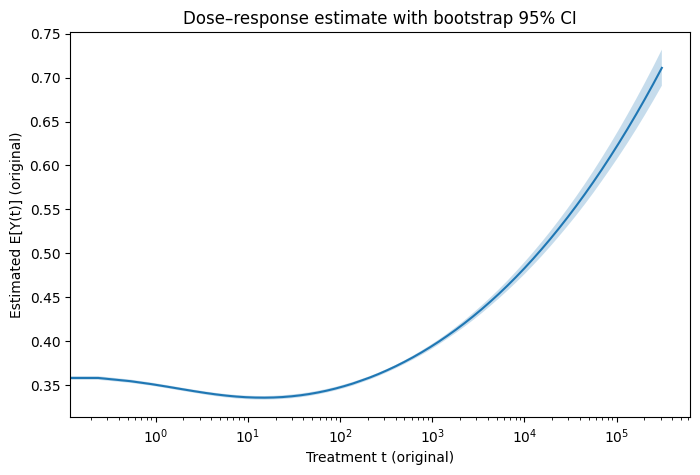

In [132]:
plt.figure(figsize=(8,5))
plt.plot(t_grid_raw, mu_hat_t_raw)
plt.fill_between(t_grid_raw, ci_lower, ci_upper, alpha=0.25)
plt.xlabel("Treatment t (original)")
plt.xscale('log')
plt.ylabel("Estimated E[Y(t)] (original)")
plt.title("Dose–response estimate with bootstrap 95% CI")
plt.show()

<hr>

## ⚖️ Проверка баланса после GPS


Balance diagnostics:
                covariate  smd_raw_mean  smd_resid_mean  smd_raw_max  \
2  sum_time_main_sec_prev      0.034798        0.033333     0.713098   
1       sum_time_sec_prev      0.043297        0.041635     0.667394   
0  sum_time_info_sec_prev      0.022653        0.021810     0.454741   
3   sessions_cnt_day_prev      0.030681        0.028163     0.261768   
4               age_years     -0.003918       -0.003235     0.056820   
5              delta_days      0.002056        0.004133     0.023942   

   smd_resid_max  
2       0.706478  
1       0.659973  
0       0.450278  
3       0.251940  
4       0.059422  
5       0.032029  


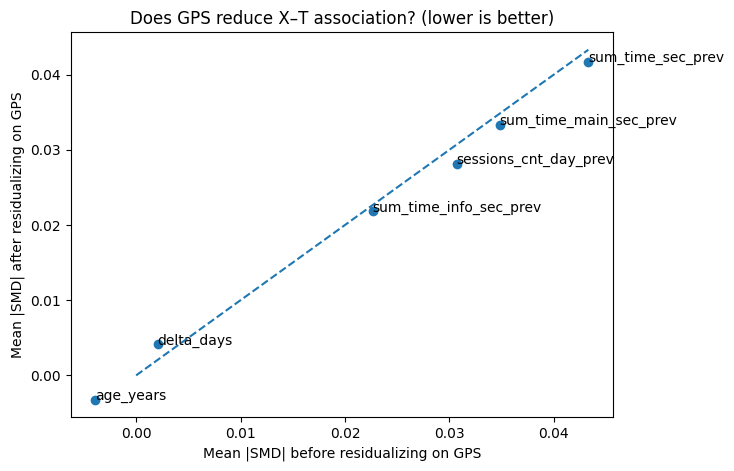

In [133]:
n_bins = 5
df['t_bin'] = pd.qcut(df['T'], q=n_bins, labels=False, duplicates="drop")

def smd(a, b):
    ma, mb = a.mean(), b.mean()
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt((sa**2 + sb**2)/2.0)
    if pooled < 1e-8:   # защита от деления на ноль
        return np.nan
    return (ma - mb) / pooled

smd_rows = []
problematic = []

for col in covariate_cols:
    cov = df[col].values
    GM = LinearRegression().fit(df[['gps']], cov.reshape(-1,1))
    cov_pred = GM.predict(df[['gps']]).ravel()
    cov_resid = cov - cov_pred
    
    raw_list, resid_list = [], []
    for b in range(n_bins):
        mask_bin = df['t_bin']==b
        mask_rest = ~mask_bin
        smd_raw = smd(cov[mask_bin], cov[mask_rest])
        smd_res = smd(cov_resid[mask_bin], cov_resid[mask_rest])
        raw_list.append(smd_raw)
        resid_list.append(smd_res)
    
    if np.any(np.isnan(raw_list)) or np.any(np.isnan(resid_list)):
        problematic.append(col)
    
    smd_rows.append({
        "covariate": col,
        "smd_raw_mean": np.nanmean(raw_list),
        "smd_resid_mean": np.nanmean(resid_list),
        "smd_raw_max": np.nanmax(raw_list),
        "smd_resid_max": np.nanmax(resid_list)
    })

smd_df = pd.DataFrame(smd_rows).sort_values('smd_raw_max', ascending=False)
print("\nBalance diagnostics:")
print(smd_df)

plt.figure(figsize=(7,5))
plt.scatter(smd_df['smd_raw_mean'], smd_df['smd_resid_mean'])
for _, r in smd_df.iterrows():
    plt.text(r['smd_raw_mean'], r['smd_resid_mean'], r['covariate'])
plt.plot([0, max(smd_df['smd_raw_mean'].max(), smd_df['smd_resid_mean'].max())],
         [0, max(smd_df['smd_raw_mean'].max(), smd_df['smd_resid_mean'].max())], linestyle='--')
plt.xlabel("Mean |SMD| before residualizing on GPS")
plt.ylabel("Mean |SMD| after residualizing on GPS")
plt.title("Does GPS reduce X–T association? (lower is better)")
plt.show()


<hr>

## ♨️ Оценка эффекта 

<img src='treat.png'>

## 💹 Считаем какой эффект мы оказались на Retention Rate 4 Weak

In [135]:
from scipy.interpolate import interp1d

# создаём интерполятор для кривой, чтобы найти новые значения на кривой
interp_mu = interp1d(t_grid_raw, mu_hat_t_raw, kind="linear", fill_value="extrapolate")

t0, t1 = 90, 120
mu0, mu1 = interp_mu(t0), interp_mu(t1)

abs_increase = mu1 - mu0
rel_increase = abs_increase / mu0 * 100

print(f"При {t0:.0f} сек RR4W = {mu0:.3f}")
print(f"При {t1:.0f} сек RR4W = {mu1:.3f}")
print(f"Абсолютный прирост = {abs_increase:.3f}")
print(f"Относительный прирост = {rel_increase:.1f}%")


При 90 сек RR4W = 0.346
При 120 сек RR4W = 0.350
Абсолютный прирост = 0.004
Относительный прирост = 1.1%


## 🛑 Заключение

<p>
    GPS — достаточно интересный метод, в котором многое интуитивно понятно: если мы знаем типичное поведение, то можем предсказать типичный исход. Насколько верны выводы, которые мы получаем с помощью GPS, — вопрос спорный, можно почитать критику метода. Но наша оценка на основе модели и доверительного интервала кажется достаточно правдоподобной - можно поверить, что улучшение раздела привело к увеличению RR на 1.1%

Лично мне он показался интересен еще тем, что в компаниях, где нет возможности или не внедрены продвинутые методы для проведения A/B-тестов вроде CUPED или стратификации, этот метод может заменить их и показать более точную оценку. Это связано с тем, что балансировка ковариат, по сути, выполняет стратификацию.

</p>